### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

### Dataset and Normalization

In [2]:
passengers = [112,118,132,129,121,135,148,148,136,119,104,118,115,126,141,135,125,149,170,170,
              158,133,114,140,145,150,178,163,172,178,199,199,184,162,146,166,171,180,193,181,
              183,218,230,242,209,191,172,194,196,196,236,235,229,243,264,272,237,211,180,201,
              204,188,235,227,234,264,302,293,259,229,203,229,242,233,267,269,270,315,364,347,
              312,274,237,278,284,277,317,313,318,374,413,405,355,306,271,306,315,301,356,348,
              355,422,465,467,404,347,305,336,340,318,362,348,363,435,491,505,404,359,310,337,
              360,342,406,396,420,472,548,559,463,407,362,405,417,391,419,461,472,535,622,606,
              508,461,390,432]

series = np.array(passengers, dtype=float)

# Normalize to [0, 1] using min-max scaling
data_min, data_max = series.min(), series.max()
norm = (series - data_min) / (data_max - data_min)

# Sliding-window: past `window` months -> next month
window = 12
X, Y = [], []
for idx in range(len(norm) - window):
    X.append(norm[idx:idx + window])
    Y.append(norm[idx + window])
X = np.array(X)
Y = np.array(Y).reshape(-1, 1)

# Chronological train/test split (no shuffling - it's a time series)
split = int(len(X) * 0.85)
X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]

print("Total windows:", len(X), " Train:", len(X_train), " Test:", len(X_test))

Total windows: 132  Train: 112  Test: 20


In [14]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((112, 12), (112, 1), (20, 12), (20, 1))

### Activation Functions

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(y):
    return y * (1 - y)

def tanh(x):
    return np.tanh(x)

def dtanh(y):
    return 1 - y ** 2

### Loss Function

In [4]:
def loss_func(y_true, y_pred):
    return 0.5*np.mean((y_true - y_pred) ** 2)

### LSTM class

Same gate structure and update rules as the original. The one real change is in
`backward()`: the original only back-propagated through the **last** timestep's cache
entry, which is fine for 3-step sequences but too weak a signal for a 12-step window.
Here `backward()` now does full **backpropagation through time (BPTT)**, accumulating
gate gradients across every timestep and carrying `dh`/`dc` backward through the
recurrence, with gradient clipping added for stability over the longer sequence.

In [ ]:
class LSTM:

    def __init__(self, input_size, hidden_size, output_size):

        self.input_size = input_size
        self.hidden_size = hidden_size

        concat_size = input_size + hidden_size

        self.Wf = np.random.randn(hidden_size, concat_size)*0.1
        self.bf = np.zeros((hidden_size, 1))

        self.Wi = /np.random.randn(hidden_size, concat_size)*0.1
        self.bi = np.zeros((hidden_size, 1))

        self.Wc = np.random.randn(hidden_size, concat_size)*0.1
        self.bc = np.zeros((hidden_size, 1))

        self.Wo = np.random.randn(hidden_size, concat_size)*0.1
        self.bo = np.zeros((hidden_size, 1))

        self.Wy = np.random.randn(output_size, hidden_size)*0.1
        self.by = np.zeros((output_size, 1))


    def forward(self, sequence):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        c_prev = c

        self.cache = []

        for x in sequence:
            x = np.array(x).reshape(-1, 1)
            z = np.vstack((h, x))
            f = sigmoid(self.Wf @ z + self.bf)
            i = sigmoid(self.Wi @ z + self.bi)
            g = tanh(self.Wc @ z + self.bc)
            o = sigmoid(self.Wo @ z + self.bo)

            c = f * c_prev + i * g
            h = o * tanh(c)

            self.cache.append((z, f, i, g, o, c, h, c_prev))
            c_prev = c

        y = self.Wy @ h + self.by
        return y


    def backward(self, target, lr, clip=5.0):

        target = np.array([[target]])

        z, f, i, g, o, c, h, c_prev = self.cache[-1]

        y = self.Wy @ h + self.by
        dy = y - target

        dWy = dy @ h.T
        dby = dy

        dWf = np.zeros_like(self.Wf); dbf = np.zeros_like(self.bf)
        dWi = np.zeros_like(self.Wi); dbi = np.zeros_like(self.bi)
        dWc = np.zeros_like(self.Wc); dbc = np.zeros_like(self.bc)
        dWo = np.zeros_like(self.Wo); dbo = np.zeros_like(self.bo)

        dh_next = self.Wy.T @ dy        # only the final timestep gets direct output gradient
        dc_next = np.zeros_like(c)

        for t in reversed(range(len(self.cache))):
            z, f, i, g, o, c, h, c_prev = self.cache[t]

            dh = dh_next
            do = dh * np.tanh(c) * dsigmoid(o)
            dc = dc_next + dh * o * dtanh(np.tanh(c))
            df = dc * c_prev * dsigmoid(f)
            di = dc * g * dsigmoid(i)
            dg = dc * i * dtanh(g)

            dWf += df @ z.T; dbf += df
            dWi += di @ z.T; dbi += di
            dWc += dg @ z.T; dbc += dg
            dWo += do @ z.T; dbo += do

            dz = self.Wf.T @ df + self.Wi.T @ di + self.Wc.T @ dg + self.Wo.T @ do
            dh_next = dz[:self.hidden_size, :]
            dc_next = dc * f

        for grad in (dWy, dby, dWf, dbf, dWi, dbi, dWc, dbc, dWo, dbo):
            np.clip(grad, -clip, clip, out=grad)

        self.Wy -= lr*dWy
        self.by -= lr*dby

        self.Wo -= lr*dWo
        self.bo -= lr*dbo

        self.Wi -= lr*dWi
        self.bi -= lr*dbi

        self.Wc -= lr*dWc
        self.bc -= lr*dbc

        self.Wf -= lr*dWf
        self.bf -= lr*dbf

### Training

In [6]:
model = LSTM(input_size=1, hidden_size=16, output_size=1)

epochs = 1000
lr = 0.1
patience = 50
patience_count = 0
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for x, y in zip(X_train, Y_train):
        pred = model.forward(x)
        loss = loss_func(y, pred)
        total_loss += loss
        model.backward(y[0], lr)

    loss_history.append(total_loss)

    if len(loss_history) > 1 and total_loss > loss_history[-2]:
        patience_count += 1
    else:
        patience_count = 0

    if epoch % 50 == 0:
        print(epoch, total_loss)

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

0 0.4363831411736158
50 0.30658404113746307
100 0.28591084240385684
150 0.27401172361054965
200 0.2649431983653912
250 0.2563821356574923
300 0.247390240407348
350 0.2378212743104182
400 0.22765812628612317
450 0.21651925532053373
500 0.20288735018406215
550 0.18433756977002688
600 0.16682676174561814
650 0.15878940235409195
700 0.15394739173785185
750 0.14887737310123206
800 0.14319328398651432
850 0.1365887080627684
900 0.12868541017922894
950 0.11986037847533923


### Evaluation & Visualization

In [ ]:
def denorm(v):
    return v * (data_max - data_min) + data_min

def evaluate(Xs, Ys):
    preds = np.array([model.forward(x)[0, 0] for x in Xs])
    mse = np.mean((preds - Ys.flatten()) ** 2)
    return preds, mse

train_preds, train_mse = evaluate(X_train, Y_train)
test_preds, test_mse = evaluate(X_test, Y_test)

test_rmse = np.sqrt(np.mean((denorm(test_preds) - denorm(Y_test.flatten())) ** 2))

print("Train MSE (normalized):", train_mse)
print("Test MSE (normalized):", test_mse)
print("Test RMSE (passengers, thousands):", test_rmse)

Train MSE (normalized): 0.0023042150022862156
Test MSE (normalized): 0.028286843480896856
Test RMSE (passengers, thousands): 87.12082982942809


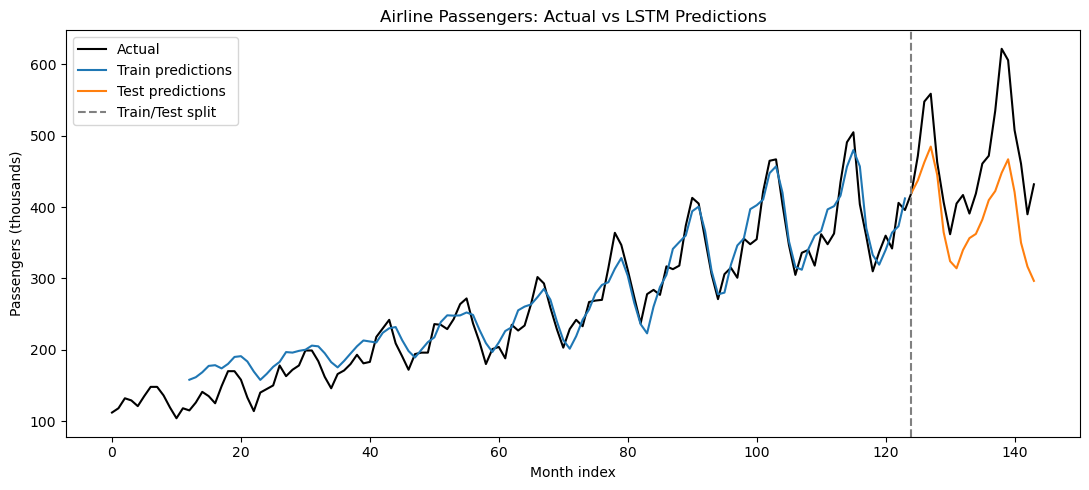

In [8]:
all_preds = np.concatenate([train_preds, test_preds])
months = np.arange(window, window + len(all_preds))

plt.figure(figsize=(11, 5))
plt.plot(np.arange(len(series)), series, label="Actual", color="black")
plt.plot(months[:len(train_preds)], denorm(train_preds), label="Train predictions", color="tab:blue")
plt.plot(months[len(train_preds):], denorm(test_preds), label="Test predictions", color="tab:orange")
plt.axvline(x=months[len(train_preds)], color="gray", linestyle="--", label="Train/Test split")
plt.title("Airline Passengers: Actual vs LSTM Predictions")
plt.xlabel("Month index")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.tight_layout()
plt.show()

### Forecast next month

Predict the month right after the end of the dataset using the last `window` known values.

In [9]:
last_window = norm[-window:]
next_pred_norm = model.forward(last_window)[0, 0]
next_pred = denorm(next_pred_norm)
print(f"Predicted next month's passengers (thousands): {next_pred:.1f}")

Predicted next month's passengers (thousands): 315.9
